# 01 - Document Loader

This notebook tests the document loading functionality for PDF and image invoices.


In [1]:
# Direct imports (project installed in editable mode)
from src.document_processor import DocumentProcessor
from src.config import config


In [2]:
# Initialize document processor
doc_processor = DocumentProcessor(config.directories.invoices)
print(f"Invoices directory: {config.directories.invoices}")


Invoices directory: data/invoices


In [3]:
# List all invoice files
files = doc_processor.list_invoice_files()
print(f"Found {len(files)} invoice files:")
for f in files:
    print(f"  - {f.name} ({f.suffix})")


Found 0 invoice files:


In [4]:
# Test loading a PDF file (if available)
pdf_files = [f for f in files if doc_processor.is_pdf(f)]

if pdf_files:
    test_pdf = pdf_files[1]
    print(f"Testing PDF: {test_pdf.name}")
    
    # Extract text
    text = doc_processor.extract_text_from_pdf(test_pdf)
    print(f"\nExtracted text ({len(text)} characters):")
    print(text[:500] + "..." if len(text) > 500 else text)
    
    # Convert to base64
    base64_data, media_type = doc_processor.file_to_base64(test_pdf)
    print(f"\nBase64 encoded: {len(base64_data)} characters")
    print(f"Media type: {media_type}")
else:
    print("No PDF files found. Please add some invoice PDFs to the invoices directory.")


No PDF files found. Please add some invoice PDFs to the invoices directory.


Testing image: FP20250158 - OrderSummary202509013059566415002039.png
Image size: (720, 1972)
Image mode: RGBA

Base64 encoded: 202968 characters
Media type: image/png


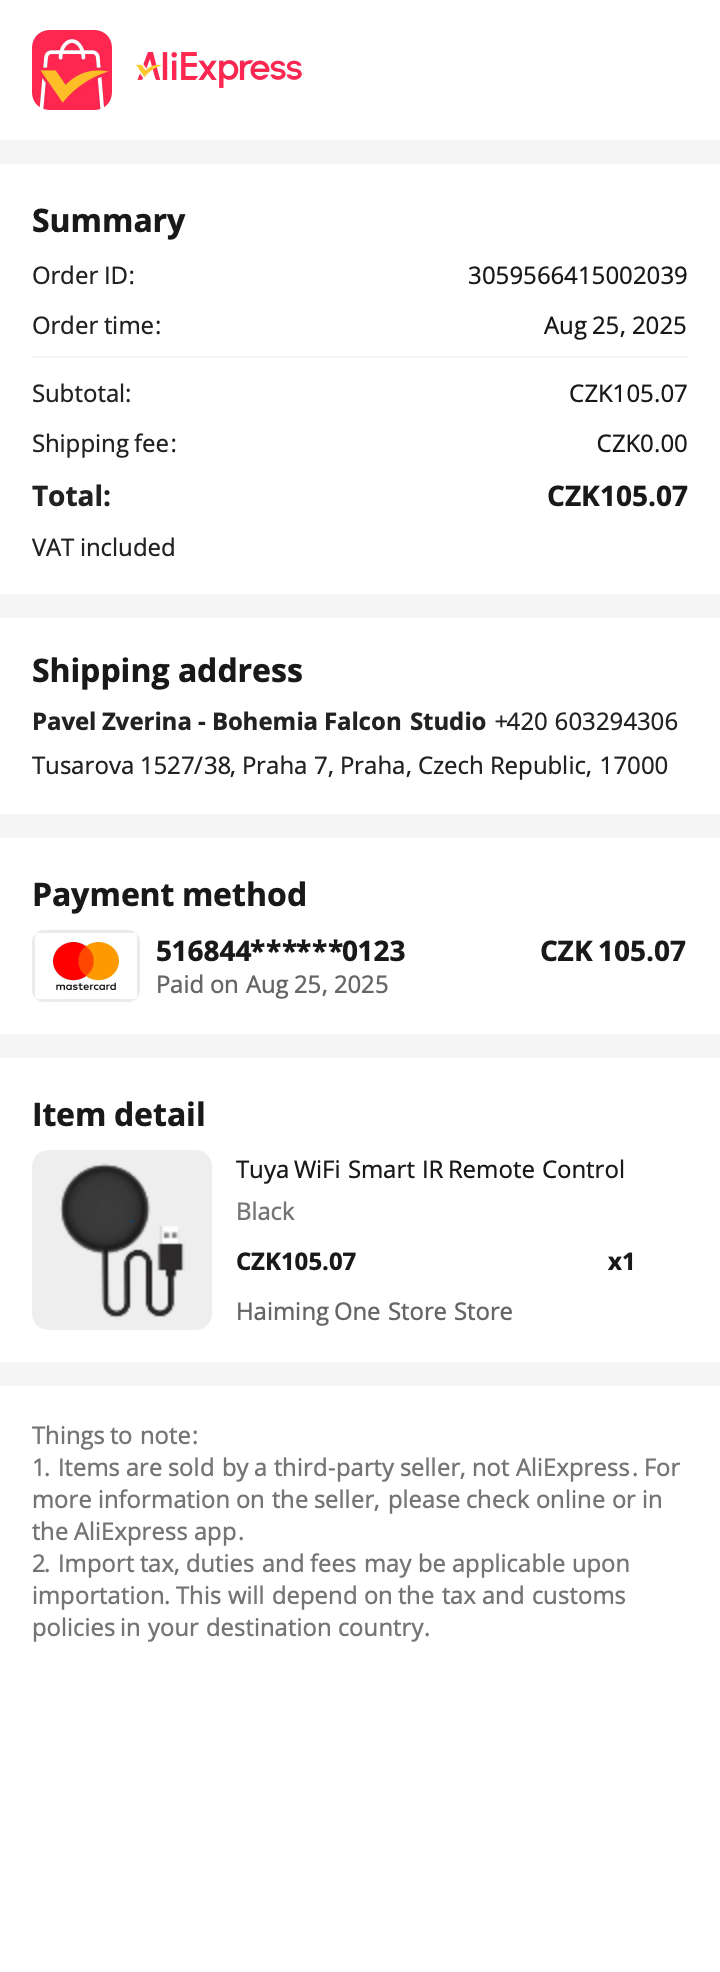

In [9]:
# Test loading an image file (if available)
image_files = [f for f in files if doc_processor.is_image(f)]

if image_files:
    test_image = image_files[0]
    print(f"Testing image: {test_image.name}")
    
    # Load image
    image = doc_processor.load_image(test_image)
    print(f"Image size: {image.size}")
    print(f"Image mode: {image.mode}")
    
    # Convert to base64
    base64_data, media_type = doc_processor.file_to_base64(test_image)
    print(f"\nBase64 encoded: {len(base64_data)} characters")
    print(f"Media type: {media_type}")
    
    # Display image (if in Jupyter)
    from IPython.display import display
    display(image)
else:
    print("No image files found. Please add some invoice images to the invoices directory.")
